# Do Unemployment Hotspots Cluster Where You'd Expect?

## The Question

State-level averages can hide a lot. This notebook drills one level further, into every one of the 162 districts DOSM published 2024 data for — the finest geographic grain Malaysia's labour statistics publish (there is no published city-level series; see Confidence & Caveats). Notebook 04 flagged Sabah as the state with the highest unemployment rate (5.7%). Does that state average reflect Sabah broadly, or is it being pulled up by a handful of extreme districts?

## The Answer

The state average badly understates it. Every one of the 15 highest-unemployment districts in Malaysia is either in Sabah or immediately adjacent — 13 of the top 15 are Sabah's rural interior districts (Tenom, Nabawan, Tongod, Pitas, and others), running **8.7% to 11.1%** unemployment, roughly double Sabah's own state-level average and 3–4x the national rate. Kuala Lumpur and Selangor, despite Notebook 05's finding that KL runs above the national rate, don't appear anywhere near the top of the district ranking at all. The real geographic story in this case study isn't the Klang Valley — it's a sharp rural interior/coastal divide inside a single state that a state-level average completely hides.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
dist = pd.read_csv('../data/processed/district_unemployment_2024.csv')
print(f'{len(dist)} districts covered, {dist["state"].nunique()} states')
dist.sort_values('unemployment_rate_pct', ascending=False).head(10)

162 districts covered, 12 states


,state,district,labour_force_thousand,unemployment_rate_pct,participation_rate_pct
97,Sabah,Tenom,24.8,11.1,69.5
85,Sabah,Nabawan,14.3,10.7,71.1
98,Sabah,Tongod,16.8,9.7,52.8
88,Sabah,Pitas,13.8,9.6,53.5
72,Sabah,Beaufort,33.2,9.4,66.4
81,Sabah,Kudat,39.5,9.4,62.2
96,Sabah,Telupid,12.1,9.3,53.4
90,Sabah,Ranau,40.3,9.3,70.2
74,Sabah,Kalabakan,30.9,9.1,69.1
94,Sabah,Tambunan,15.0,9.0,70.0


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## The 15 highest-unemployment districts nationally, 2024

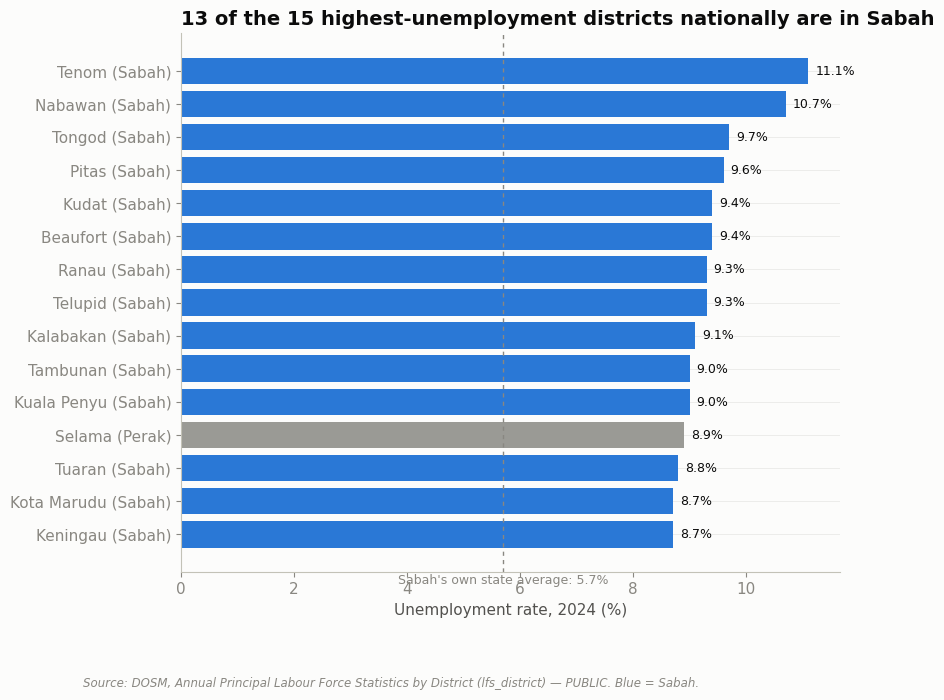

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 7))
top15 = dist.sort_values('unemployment_rate_pct', ascending=False).head(15).sort_values('unemployment_rate_pct')
colors = [ACCENT_1 if s == 'Sabah' else GRAY for s in top15['state']]
labels = [f"{d} ({s})" for d, s in zip(top15['district'], top15['state'])]
bars = ax.barh(labels, top15['unemployment_rate_pct'], color=colors)
for b in bars:
    ax.annotate(f'{b.get_width():.1f}%', xy=(b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)
ax.axvline(5.7, color=INK_MUTED, linewidth=1, linestyle=(0, (3, 3)))
ax.annotate("Sabah's own state average: 5.7%", xy=(5.7, -0.9), xytext=(0, -14),
            textcoords='offset points', fontsize=9, color=INK_MUTED, ha='center')
ax.set_title('13 of the 15 highest-unemployment districts nationally are in Sabah', loc='left')
ax.set_xlabel('Unemployment rate, 2024 (%)')
add_source(ax.figure, 'Source: DOSM, Annual Principal Labour Force Statistics by District (lfs_district) \u2014 PUBLIC. Blue = Sabah.')
plt.show()

## Spread of district unemployment rates within each state

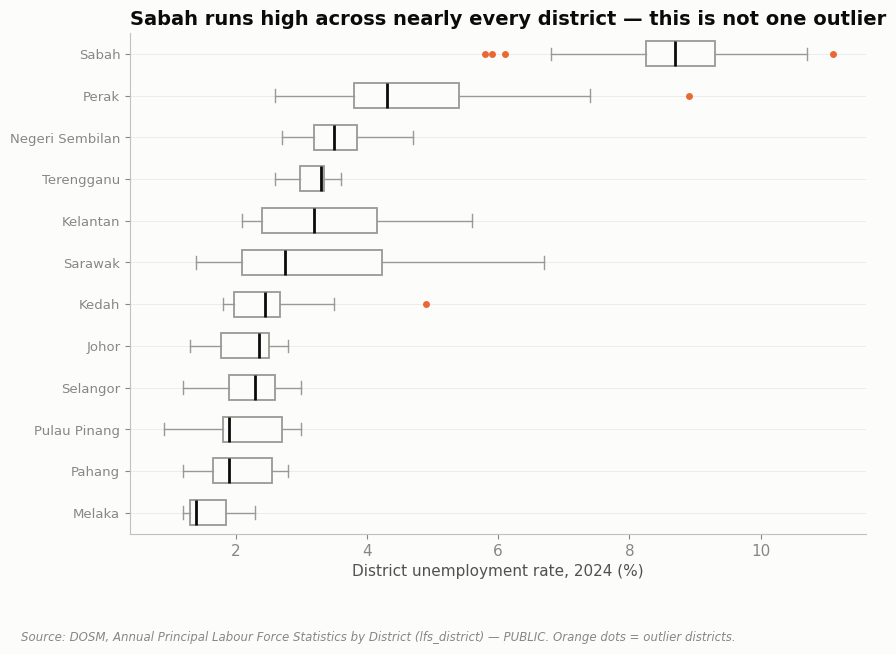

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
dist_valid = dist.dropna(subset=['unemployment_rate_pct'])  # 6 districts (1 Sabah, 5 Sarawak) have no 2024 figure — see DATA_DICTIONARY.md
order = dist_valid.groupby('state')['unemployment_rate_pct'].median().sort_values().index
box_data = [dist_valid[dist_valid['state'] == s]['unemployment_rate_pct'].values for s in order]
bp = ax.boxplot(box_data, vert=False, patch_artist=True, widths=0.6,
                 medianprops=dict(color=INK, linewidth=2),
                 boxprops=dict(facecolor=SURFACE, edgecolor=GRAY, linewidth=1.3),
                 whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                 flierprops=dict(marker='o', markerfacecolor=ACCENT_2, markeredgecolor='none', markersize=5))
ax.set_yticks(range(1, len(order)+1)); ax.set_yticklabels(order, fontsize=9.5)
ax.set_title('Sabah runs high across nearly every district \u2014 this is not one outlier', loc='left')
ax.set_xlabel('District unemployment rate, 2024 (%)')
add_source(ax.figure, 'Source: DOSM, Annual Principal Labour Force Statistics by District (lfs_district) \u2014 PUBLIC. Orange dots = outlier districts.')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's finding — kept separate from the PUBLIC LFS figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

Independent reporting on Sabah's interior districts points to geographic isolation from the state's own economic core, not just a lagging national economy. All eight of Sabah's officially poorest districts are rural and interior, far from Kota Kinabalu — the state's primary economic hub — and infrastructure investment has not closed that gap: despite billions channelled through the Sabah Development Corridor, roads in Nabawan, Pitas, and Tongod remain unpaved dirt tracks, and some villages in Nabawan have had no road access at all since independence. Poor roads make it hard for interior farmers to get produce to market, compounding the disadvantage. This is a case where the district drill-down reveals a mechanism a state or national view genuinely cannot: it isn't that Sabah as a whole lacks economic opportunity, it's that opportunity in Sabah is concentrated near the coast, and interior districts are geographically cut off from it in a way that shows up nowhere above the district level.

**Sources:** [BERNAMA, "Insights Into Sabah's Rural And Interior Poverty"](https://www.bernama.com/en/news.php/bfokus/news.php?id=2364927); [BERNAMA, "Remote Nabawan Villages Still Without Road Access Since Independence"](https://www.bernama.com/en/region/news.php?id=2583976).

## Strategic Recommendation

- **A business or policymaker treating "Sabah" as one labour market is missing the real pattern.** The state figure (5.7%) is a genuine average of a coastal economy running closer to the national rate and an interior economy running 8.7–11.1% — two very different places to make an investment or intervention decision about.
- **Interior Sabah's problem reads as market-access, not labour-supply.** Infrastructure — specifically road access to markets — is the recurring explanation in independent reporting, which points toward a different kind of intervention (connectivity) than a generic "more jobs" framing would suggest.

## Confidence & Caveats

- **There is no published city-level labour statistic in Malaysia — district is the floor.** A city like Petaling Jaya or Kota Kinabalu itself is treated as part of a larger administrative district and is not separately surveyed or reported by DOSM. This notebook's district layer is the most granular public data can support for this case study.
- **6 districts (1 in Sabah, 5 in Sarawak) had no 2024 figure published at all** and are excluded from this notebook's charts — a real, verified gap in DOSM's own district-level release, not a processing error. See `DATA_DICTIONARY.md`.
- **DOSM's own methodology states the Labour Force Survey is designed for national and state-level reliability first** — district-level estimates, especially for smaller or more remote districts, carry wider uncertainty than the state-level figures in Notebook 04. Read district-level rankings as directional, not precise to a decimal point.